####### GROMACS-T4-GPU-CONNECTED-IN-COLAB-INSTALLED-IN-DRIVE-MOUNTED #######

In [ ]:
### 7EW0 - Febuxostat  ##

In [ ]:
### REFERED GROMAC TUTORIAL FOR PROTEIN-LIGAND SIMULATION
### Refered YOUtube https://www.youtube.com/watch?v=jeiWI6uBWO8&t=2240s
 ## [http://www.mdtutorials.com/gmx/complex/index.html]

In [ ]:
#### FIRST CONNECT TO T4-GPU , THEN RUN THE FOLLOWING CODES
####. GROMAC successfully CONNECTED TO GPU ####

In [ ]:
## check T4-GPU connection
!nvidia-smi

Fri Mar 20 07:15:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
# Step 1: Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

# Set permanent install path inside Drive
import os
gromacs_path = "/content/drive/MyDrive/gromacs-2021.4"

# Check if already installed
if not os.path.exists(gromacs_path):
    print("🚀 Installing GROMACS for the first time... (this will take ~20–30 min)")
    !apt-get update -qq
    !apt-get install -y build-essential cmake git wget unzip libfftw3-dev libgsl-dev

    # Download and extract GROMACS
    !wget -q http://ftp.gromacs.org/pub/gromacs/gromacs-2021.4.tar.gz -O gromacs-2021.4.tar.gz
    !tar -xf gromacs-2021.4.tar.gz
    %cd gromacs-2021.4
    !mkdir build
    %cd build
    !cmake .. -DGMX_BUILD_OWN_FFTW=ON \
              -DREGRESSIONTEST_DOWNLOAD=ON \
              -DGMX_GPU=CUDA \
              -DGMX_CUDA_TARGET_SM="75" \
              -DCMAKE_INSTALL_PREFIX={gromacs_path}
    !make -j4
    !make install
    print("✅ GROMACS successfully installed and saved in Drive!")

    # Clean temporary build files
    %cd /content
    !rm -rf gromacs-2021.4 gromacs-2021.4.tar.gz
else:
    print("✅ GROMACS already installed in Drive — skipping build.")

# Add GROMACS to PATH
os.environ["PATH"] = f"{gromacs_path}/bin:" + os.environ["PATH"]

# ✅ Set a permanent working directory for all your MD files
work_dir = "/content/drive/MyDrive/MD_work"
os.makedirs(work_dir, exist_ok=True)
%cd $work_dir

print(f"✅ Working directory set to: {work_dir}")
!gmx --version

✅ GROMACS already installed in Drive — skipping build.
/content/drive/MyDrive/MD_work
✅ Working directory set to: /content/drive/MyDrive/MD_work
/bin/bash: line 1: /content/drive/MyDrive/gromacs-2021.4/bin/gmx: Permission denied


In [3]:
!chmod -R +x /content/drive/MyDrive/gromacs-2021.4/bin

In [4]:
!gmx --version

                         :-) GROMACS - gmx, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Murtol

In [ ]:
################################### START TUTORIAL #####################################

In [ ]:
# GROMACS Tutorial
# Step One: Prepare the Protein Topology

In [ ]:
# Step 1: Download the protein structure
## OR OPEN docked protein-ligand and save seperate files cleaned files as protein and ligand
## add H2 to ligand and save as .mol2 file
## upload this ligand.mol2 on swissparam site to get topology files

In [ ]:
# Open the PDB file in VMD, PyMOL, or UCSF Chimera to inspect it visually.

# You’ll notice:
# 	•	Protein chain(s)
# 	•	Ligand  bound in the protein cavity — keeping only the protein and the ligand.

In [ ]:
## UPLOAD PDB FILE ....THIS CODE WILL UPLOAD THE FILE IN PERTICULR PATH YOU HAD SET
from google.colab import files
uploaded = files.upload() #  # select files ### UPLOAD FILE 6NPM.pdb [only protein]

Saving 7EW0-dp.pdb to 7EW0-dp.pdb


In [ ]:
# Remove water molecule
#!grep -v HOH 6NPM.pdb > 6NPM_protein.pdb

In [ ]:
# remove any HETATM or ATOM lines for residue name KVD, write new file
#!grep -v " KVD " 6NPM_protein.pdb > 6NPM_clean.pdb

In [ ]:
# Protein topology
!gmx pdb2gmx -f 7EW0-dp.pdb -o 7EW0_processed.gro -water tip3p -ignh # Select force field when prompted (e.g., 8 for CHARMM27)

                     :-) GROMACS - gmx pdb2gmx, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
## upload only ligand.pdb with hydrogen added saved and uploaded that pdb to swiss param to get ligand.zip files in bulk
## then upload all zip ligand bulk files here

from google.colab import files
uploaded = files.upload() ##  LIG.pdb all 7 LIG files from swissparam [FABU]]

Saving LIG.crd to LIG.crd
Saving LIG.pdb to LIG.pdb
Saving LIG.itp to LIG.itp
Saving LIG.psf to LIG.psf
Saving LIG.rtf to LIG.rtf
Saving LIG.par to LIG.par
Saving LIG.mol2 to LIG.mol2


In [ ]:
!gmx editconf -f LIG.pdb -o lig.gro ## change output file name with different ligand

                     :-) GROMACS - gmx editconf, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu M

In [ ]:
## Edit the topol.top file to include the ligand topology from lig.gro , copy paste  as shown in tutorial
## refered tutorial link : http://www.mdtutorials.com/gmx/complex/02_topology.html

In [ ]:
!gmx editconf -f 7EW0_processed.gro -o 7EW0_newbox.gro -c -d 1.2 -bt cubic # # protein is in the box

                     :-) GROMACS - gmx editconf, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu M

In [ ]:
!gmx solvate -cp 7EW0_newbox.gro -cs spc216.gro -o 7EW0_solv.gro -p topol.top

                     :-) GROMACS - gmx solvate, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
## upload md parameter files all
from google.colab import files
uploaded = files.upload()  # select files ### UPLOAD FILES

Saving npt.mdp to npt.mdp
Saving md.mdp to md.mdp
Saving ions.mdp to ions.mdp
Saving em.mdp to em.mdp
Saving nvt.mdp to nvt.mdp


In [ ]:
## make changes in topol.top file as "# LIG.prm to LIG.itp " remove LIG.itp from last
## and check SOL in next line


In [ ]:
!gmx grompp -f ions.mdp -c 7EW0_solv.gro -p topol.top -o ions.tpr

                      :-) GROMACS - gmx grompp, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
!gmx genion -s ions.tpr -o 7EW0_solv_ions.gro -p topol.top -pname NA -nname CL -neutral ## 15 for SOL

                      :-) GROMACS - gmx genion, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
!gmx grompp -f em.mdp -c 7EW0_solv_ions.gro -p topol.top -o em.tpr

                      :-) GROMACS - gmx grompp, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
!gmx mdrun -v -deffnm em # 15 MINS

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
!gmx energy -f em.edr -o potential.xvg ## 12 and 0 for potential

                      :-) GROMACS - gmx energy, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
!gmx make_ndx -f lig.gro -o index_lig.ndx # selext .. 0 & ! a H* and type q

                     :-) GROMACS - gmx make_ndx, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu M

In [ ]:
!gmx genrestr -f lig.gro -n index_lig.ndx -o posre_lig.itp -fc 1000 1000 1000 ## type 3

                     :-) GROMACS - gmx genrestr, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu M

In [ ]:
!gmx make_ndx -f em.gro -o index.ndx # 1 | 13

                     :-) GROMACS - gmx make_ndx, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu M

In [ ]:
## .  add this in topol.top file

# ; Ligand position restraints
#ifdef POSRES_LIG
#include "posre_lig.itp"
#endif

In [ ]:
!gmx grompp -f nvt.mdp -c em.gro -r em.gro -p topol.top -n index.ndx -o nvt.tpr

                      :-) GROMACS - gmx grompp, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
!gmx mdrun -v -deffnm nvt

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
!gmx energy -f nvt.edr -o temperature.xvg

                      :-) GROMACS - gmx energy, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
!gmx grompp -f npt.mdp -c nvt.gro -t nvt.cpt -r nvt.gro -p topol.top -n index.ndx -o npt.tpr

                      :-) GROMACS - gmx grompp, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
!gmx mdrun -v -deffnm npt

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
!gmx energy -f npt.edr -o pressure.xvg

                      :-) GROMACS - gmx energy, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
!gmx energy -f npt.edr -o density.xvg

                      :-) GROMACS - gmx energy, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
!gmx grompp -f md.mdp -c npt.gro -t npt.cpt -p topol.top -n index.ndx -o md_0_10.tpr ##check how much to set
## SELECTED ONLY NSTEPS AT 2500000 [5ns]

                      :-) GROMACS - gmx grompp, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
!gmx mdrun -v -deffnm md_0_10

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
#### CONTINUE MD-RUN IF GETS DISCONNECTED GPU SERVER ####- Just delete old notebook or change name of note book
!gmx mdrun -v -deffnm md_0_10 -cpi md_0_10.cpt -append

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
!gmx mdrun -v -deffnm md_0_10 -cpi md_0_10.cpt -append

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
# 1. Update your md.mdp file
## NEXT RUN for 50ns ---updated md.mdp to 25000000 steps

In [ ]:
## 2. Create a new tpr file using the checkpoint
## UPDATED for 50NS

!gmx grompp -f md.mdp -c md_0_10.gro -t md_0_10.cpt -p topol.top -n index.ndx -o md_10_50.tpr



                      :-) GROMACS - gmx grompp, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
## Step 3: This will continue and appending to md_0_10
!gmx mdrun -s md_10_50.tpr -cpi md_0_10.cpt -append -deffnm md_0_10 -v

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
## Step 4: Continue appending .....
!gmx mdrun -s md_10_50.tpr -cpi md_0_10.cpt -append -deffnm md_0_10 -v

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
## Step 4: Continue appending .....
!gmx mdrun -s md_10_50.tpr -cpi md_0_10.cpt -append -deffnm md_0_10 -v

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
###### NO APPENDING
!gmx mdrun -s md_10_50.tpr -cpi md_0_10.cpt -noappend -deffnm md_0_10 -v

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
###### NO APPENDING
!gmx mdrun -s md_10_50.tpr -cpi md_0_10.cpt -noappend -deffnm md_0_10 -v

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
###### NO APPENDING
!gmx mdrun -s md_10_50.tpr -cpi md_0_10.cpt -noappend -deffnm md_0_10 -v

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
###### NO APPENDING
!gmx mdrun -s md_10_50.tpr -cpi md_0_10.cpt -noappend -deffnm md_0_10 -v

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
###### NO APPENDING
!gmx mdrun -s md_10_50.tpr -cpi md_0_10.cpt -noappend -deffnm md_0_10 -v

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
###### NO APPENDING
!gmx mdrun -s md_10_50.tpr -cpi md_0_10.cpt -noappend -deffnm md_0_10 -v

                      :-) GROMACS - gmx mdrun, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
!ls *.xtc

md_0_10_center.xtc    md_0_10.part0018.xtc  md_0_10.xtc    npt.xtc
md_0_10.part0015.xtc  md_0_10.part0019.xtc  md_center.xtc  nvt.xtc
md_0_10.part0016.xtc  md_0_10.part0020.xtc  md_fit.xtc
md_0_10.part0017.xtc  md_0_10.part0021.xtc  md_full.xtc


In [ ]:
!gmx trjcat -f md_0_10.xtc md_0_10.part0015.xtc md_0_10.part0016.xtc md_0_10.part0017.xtc md_0_10.part0018.xtc md_0_10.part0019.xtc md_0_10.part0020.xtc md_0_10.part0021.xtc -o md_clean.xtc

                      :-) GROMACS - gmx trjcat, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
!gmx trjconv -s md_10_50.tpr -f md_fixed.xtc -o md_clean_final.xtc -b 0 -e 15000

                     :-) GROMACS - gmx trjconv, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
####### TRajectory ANALYSIS ###########

In [ ]:
!gmx trjconv -s md_10_50.tpr -f md_clean_final.xtc -o md_fit_final.xtc -fit rot+trans

                     :-) GROMACS - gmx trjconv, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [5]:
!gmx trjconv -s md_10_50.tpr -f md_fit_final.xtc -o frame.pdb -dump 10000 # Selected 17: 'non-Water'

                     :-) GROMACS - gmx trjconv, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [6]:
!gmx trjconv -s md_10_50.tpr -f md_fit_final.xtc -o frame_12.6ns.pdb -dump 12600 # Selected 17: 'non-Water'

                     :-) GROMACS - gmx trjconv, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [7]:
!gmx trjconv -s md_10_50.tpr -f md_fit_final.xtc -o frame_14.2ns.pdb -dump 14200

                     :-) GROMACS - gmx trjconv, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [8]:
!gmx trjconv -s md_10_50.tpr -f md_fit_final.xtc -o frame_15ns.pdb -dump 15000

                     :-) GROMACS - gmx trjconv, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

In [ ]:
## RMSD
!gmx rms -s md_10_50.tpr -f md_fit_final.xtc -o rmsd.xvg -tu ns

                       :-) GROMACS - gmx rms, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Murt

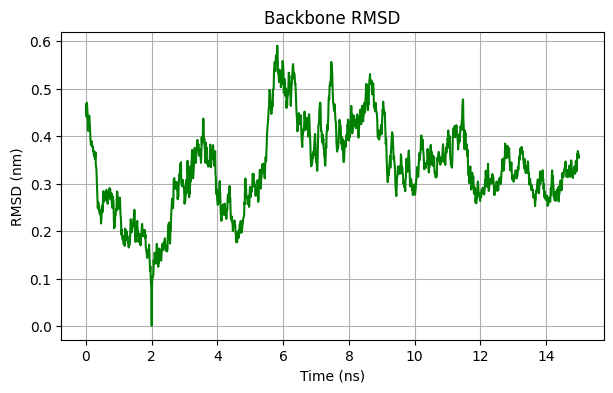

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Read file safely and clean it ---
with open("rmsd.xvg") as f:
    lines = [line for line in f if not line.startswith(('@', '#'))]

# --- Extract numeric data ---
cleaned = []
for line in lines:
    # remove multiple spaces and split
    parts = re.split(r'\s+', line.strip())
    if len(parts) >= 2:  # at least 2 columns: Time, RMSD
        cleaned.append(parts[:2])

# --- Create DataFrame ---
data = pd.DataFrame(cleaned, columns=["Time", "RMSD"]).astype(float)

# --- Plot RMSD ---
plt.figure(figsize=(7,4))
plt.plot(data["Time"], data["RMSD"], color='green')
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
plt.title("Backbone RMSD")
plt.grid(True)
plt.show()

In [ ]:
# RMSD ligand
!gmx rms -s md_10_50.tpr -f md_fit_final.xtc -o rmsd-lig.xvg -tu ns

                       :-) GROMACS - gmx rms, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Murt

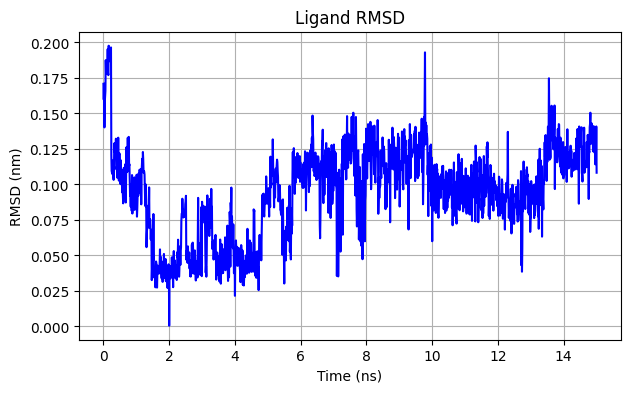

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Read file safely and clean it ---
with open("rmsd-lig.xvg") as f:
    lines = [line for line in f if not line.startswith(('@', '#'))]

# --- Extract numeric data ---
cleaned = []
for line in lines:
    # remove multiple spaces and split
    parts = re.split(r'\s+', line.strip())
    if len(parts) >= 2:  # at least 2 columns: Time, RMSD
        cleaned.append(parts[:2])

# --- Create DataFrame ---
data = pd.DataFrame(cleaned, columns=["Time", "RMSD"]).astype(float)

# --- Plot RMSD ---
plt.figure(figsize=(7,4))
plt.plot(data["Time"], data["RMSD"], color='blue')
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
plt.title("Ligand RMSD")
plt.grid(True)
plt.show()

In [ ]:
# pro-lig complex
!gmx make_ndx -f md_0_10.gro -o index_n.ndx

                     :-) GROMACS - gmx make_ndx, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu M

In [ ]:
## RMSD PRO-LIG
!gmx rms -s md_10_50.tpr -f md_fit_final.xtc -o rmsd-lig-pro.xvg -tu ns -n index_n.ndx

                       :-) GROMACS - gmx rms, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Murt

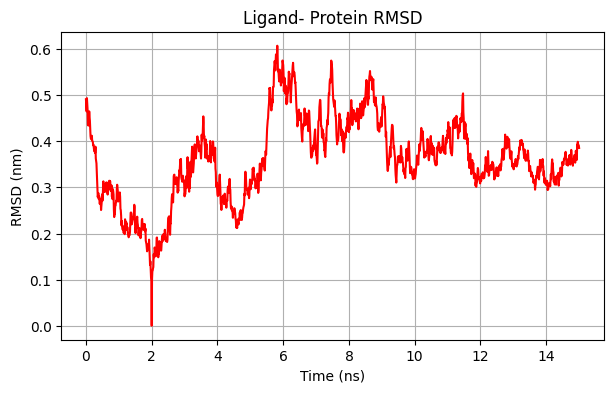

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Read file safely and clean it ---
with open("rmsd-lig-pro.xvg") as f:
    lines = [line for line in f if not line.startswith(('@', '#'))]

# --- Extract numeric data ---
cleaned = []
for line in lines:
    # remove multiple spaces and split
    parts = re.split(r'\s+', line.strip())
    if len(parts) >= 2:  # at least 2 columns: Time, RMSD
        cleaned.append(parts[:2])

# --- Create DataFrame ---
data = pd.DataFrame(cleaned, columns=["Time", "RMSD"]).astype(float)

# --- Plot RMSD ---
plt.figure(figsize=(7,4))
plt.plot(data["Time"], data["RMSD"], color='red')
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
plt.title("Ligand- Protein RMSD")
plt.grid(True)
plt.show()

In [5]:
## RMSD : For  Fit : backbone and RMSD: Pro_lig complex #### Complex
!gmx rms -s md_10_50.tpr -f md_fit_final.xtc -o rmsd-pro_LIG_complex.xvg -tu ns -n index_n.ndx

                       :-) GROMACS - gmx rms, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Murt

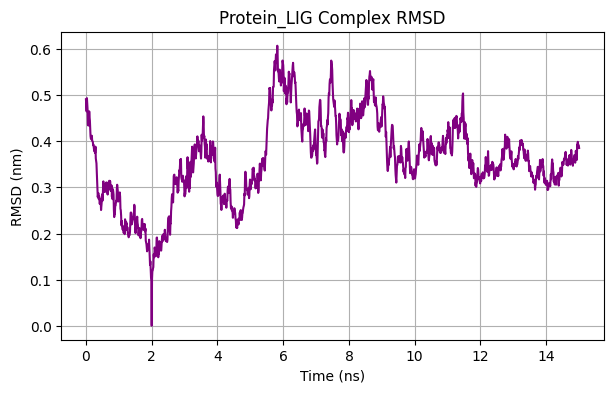

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Read file safely and clean it ---
with open("rmsd-pro_LIG_complex.xvg") as f:
    lines = [line for line in f if not line.startswith(('@', '#'))]

# --- Extract numeric data ---
cleaned = []
for line in lines:
    # remove multiple spaces and split
    parts = re.split(r'\s+', line.strip())
    if len(parts) >= 2:  # at least 2 columns: Time, RMSD
        cleaned.append(parts[:2])

# --- Create DataFrame ---
data = pd.DataFrame(cleaned, columns=["Time", "RMSD"]).astype(float)

# --- Plot RMSD ---
plt.figure(figsize=(7,4))
plt.plot(data["Time"], data["RMSD"], color='purple')
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
plt.title("Protein_LIG Complex RMSD")
plt.grid(True)
plt.show()

In [1]:
# import matplotlib.pyplot as plt
# import pandas as pd
# from io import StringIO  # ✅ use built-in StringIO

# # Function to read .xvg file (ignores comments)
# def read_xvg(filename):
#     with open(filename, 'r') as f:
#         lines = [line for line in f if not line.startswith(('#', '@'))]
#     data = pd.read_csv(StringIO(''.join(lines)),
#                        delim_whitespace=True, header=None, names=['Time (ns)', 'RMSD (nm)'])
#     return data

# # Read both RMSD files
# protein = read_xvg("rmsd.xvg")
# prolig = read_xvg("rmsd-pro_LIG_complex.xvg")

# # Plot both curves
# plt.figure(figsize=(8,5))
# plt.plot(protein['Time (ns)'], protein['RMSD (nm)'], label='Protein RMSD', color='blue', linewidth=2)
# plt.plot(prolig['Time (ns)'], prolig['RMSD (nm)'], label='Protein-Ligand RMSD', color='red', linewidth=2)

# # Plot formatting
# plt.xlabel('Time (ns)', fontsize=12)
# plt.ylabel('RMSD (nm)', fontsize=12)
# plt.title('RMSD Comparison: Protein vs Protein-Ligand', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.tight_layout()

# # Save plot (optional)
# # plt.savefig("RMSD_Protein_vs_ProteinLigand.png", dpi=300)

# # Show plot
# plt.show()

In [ ]:
## Radius of Gyration
!gmx gyrate -s md_10_50.tpr -f md_fit_final.xtc -o gyrate.xvg

                      :-) GROMACS - gmx gyrate, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

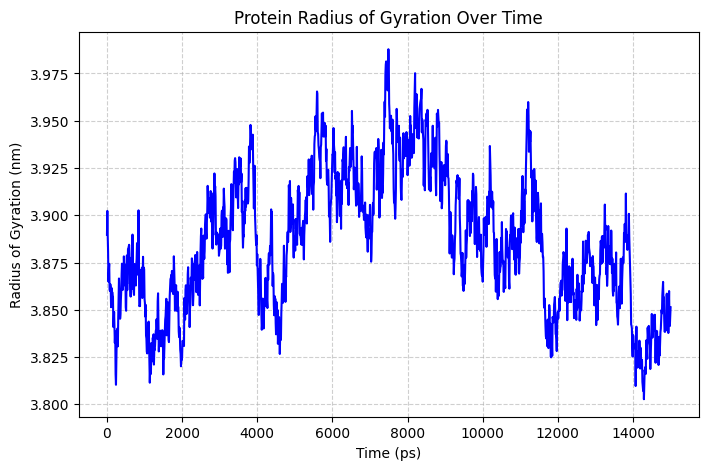

Average Rg: 3.886 nm ± 0.036 nm


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Clean and load gyrate.xvg safely ---
with open("gyrate.xvg") as f:
    lines = [line for line in f if not line.startswith(('@', '#'))]

cleaned = []
for line in lines:
    # Split by any amount of whitespace
    parts = re.split(r'\s+', line.strip())
    # Only take numeric columns (first two if too many)
    if len(parts) >= 2:
        cleaned.append(parts[:2])  # Time, Rg (first two columns only)

# --- Create DataFrame ---
data = pd.DataFrame(cleaned, columns=["Time", "Rg"]).astype(float)

# --- Plot Radius of Gyration ---
plt.figure(figsize=(8,5))
plt.plot(data["Time"], data["Rg"], color="blue", linewidth=1.5)
plt.xlabel("Time (ps)")
plt.ylabel("Radius of Gyration (nm)")
plt.title("Protein Radius of Gyration Over Time")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# --- Optional: Compute Mean and SD ---
mean_rg = data["Rg"].mean()
std_rg = data["Rg"].std()
print(f"Average Rg: {mean_rg:.3f} nm ± {std_rg:.3f} nm")

In [8]:
!gmx gyrate -s md_10_50.tpr -f md_fit_final.xtc -o gyrate-pro-lig -n index_n.ndx

                      :-) GROMACS - gmx gyrate, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mu

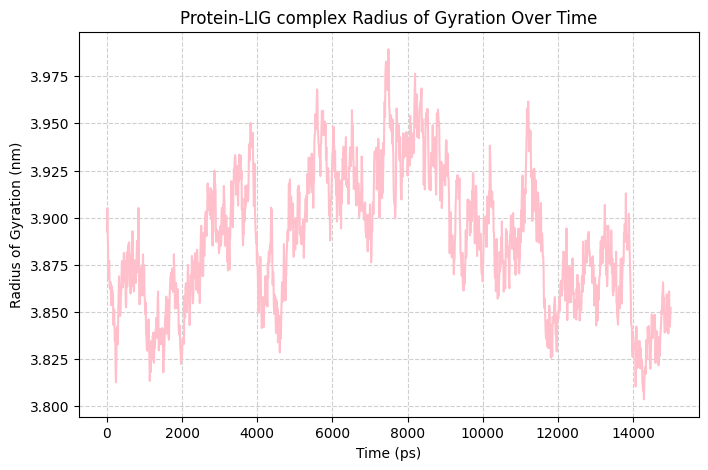

Average Rg: 3.888 nm ± 0.036 nm


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Clean and load gyrate.xvg safely ---
with open("gyrate-pro-lig.xvg") as f:
    lines = [line for line in f if not line.startswith(('@', '#'))]

cleaned = []
for line in lines:
    # Split by any amount of whitespace
    parts = re.split(r'\s+', line.strip())
    # Only take numeric columns (first two if too many)
    if len(parts) >= 2:
        cleaned.append(parts[:2])  # Time, Rg (first two columns only)

# --- Create DataFrame ---
data = pd.DataFrame(cleaned, columns=["Time", "Rg"]).astype(float)

# --- Plot Radius of Gyration ---
plt.figure(figsize=(8,5))
plt.plot(data["Time"], data["Rg"], color="pink", linewidth=1.5)
plt.xlabel("Time (ps)")
plt.ylabel("Radius of Gyration (nm)")
plt.title("Protein-LIG complex Radius of Gyration Over Time")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# --- Optional: Compute Mean and SD ---
mean_rg = data["Rg"].mean()
std_rg = data["Rg"].std()
print(f"Average Rg: {mean_rg:.3f} nm ± {std_rg:.3f} nm")

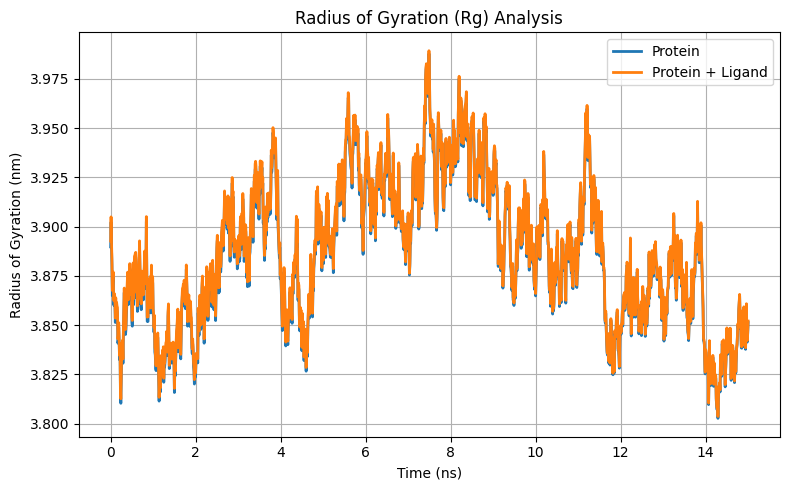

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Function to read .xvg file
def read_xvg(file):
    data = []
    with open(file, 'r') as f:
        for line in f:
            if line.startswith(('#', '@')):
                continue
            data.append([float(x) for x in line.split()])
    return np.array(data)

# Load both files
rg_protein = read_xvg('gyrate.xvg')
rg_complex = read_xvg('gyrate-pro-lig.xvg')

# Extract time and Rg
time1 = rg_protein[:, 0]
rg1 = rg_protein[:, 1]

time2 = rg_complex[:, 0]
rg2 = rg_complex[:, 1]

# Convert time from ps → ns (optional but recommended)
time1 = time1 / 1000
time2 = time2 / 1000

# Plot
plt.figure(figsize=(8,5))

plt.plot(time1, rg1, label='Protein', linewidth=2)
plt.plot(time2, rg2, label='Protein + Ligand', linewidth=2)

# Labels
plt.xlabel('Time (ns)')
plt.ylabel('Radius of Gyration (nm)')
plt.title('Radius of Gyration (Rg) Analysis')

# Legend & grid
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
# SASA
!gmx sasa -s md_10_50.tpr -f md_fit_final.xtc -o SASA.xvg # protein

                       :-) GROMACS - gmx sasa, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

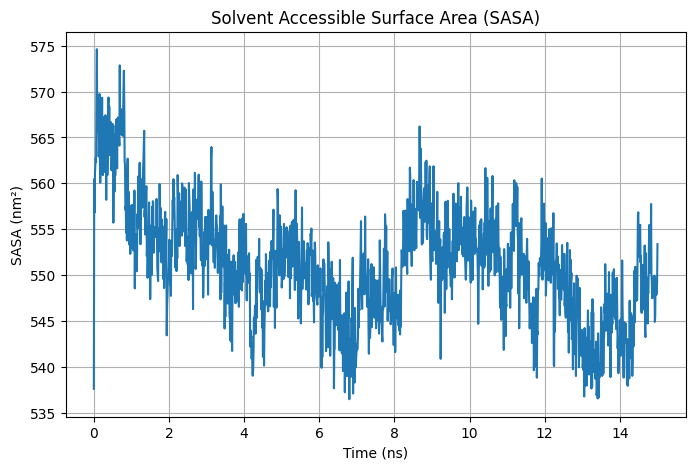

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load XVG file (skip comments and metadata)
time = []
sasa = []

with open("SASA.xvg", "r") as f:
    for line in f:
        if line.startswith(("#", "@")):
            continue
        data = line.split()
        time.append(float(data[0]))   # Time (ps)
        sasa.append(float(data[1]))   # SASA (nm^2)

# Convert to numpy arrays
time = np.array(time) / 1000   # convert ps → ns
sasa = np.array(sasa)

# Plot
plt.figure(figsize=(8,5))
plt.plot(time, sasa)
plt.xlabel("Time (ns)")
plt.ylabel("SASA (nm²)")
plt.title("Solvent Accessible Surface Area (SASA)")
plt.grid()

plt.show()

In [11]:
!gmx sasa -s md_10_50.tpr -f md_fit_final.xtc -o SASA-pro-lig.xvg -n index_n.ndx

                       :-) GROMACS - gmx sasa, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

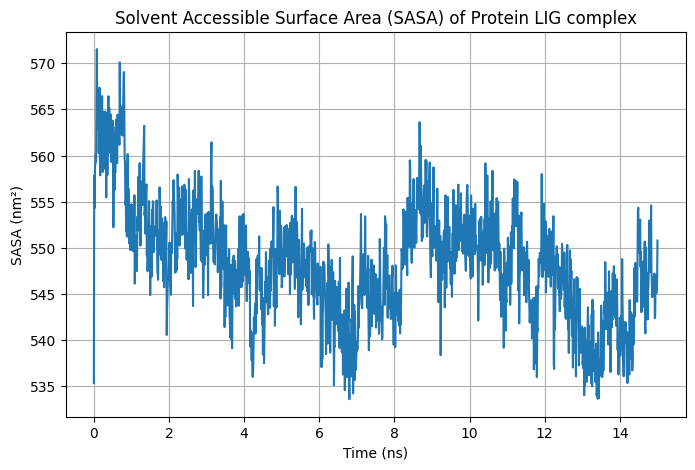

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Load XVG file (skip comments and metadata)
time = []
sasa = []

with open("SASA-pro-lig.xvg", "r") as f:
    for line in f:
        if line.startswith(("#", "@")):
            continue
        data = line.split()
        time.append(float(data[0]))   # Time (ps)
        sasa.append(float(data[1]))   # SASA (nm^2)

# Convert to numpy arrays
time = np.array(time) / 1000   # convert ps → ns
sasa = np.array(sasa)

# Plot
plt.figure(figsize=(8,5))
plt.plot(time, sasa)
plt.xlabel("Time (ns)")
plt.ylabel("SASA (nm²)")
plt.title("Solvent Accessible Surface Area (SASA) of Protein LIG complex")
plt.grid()

plt.show()

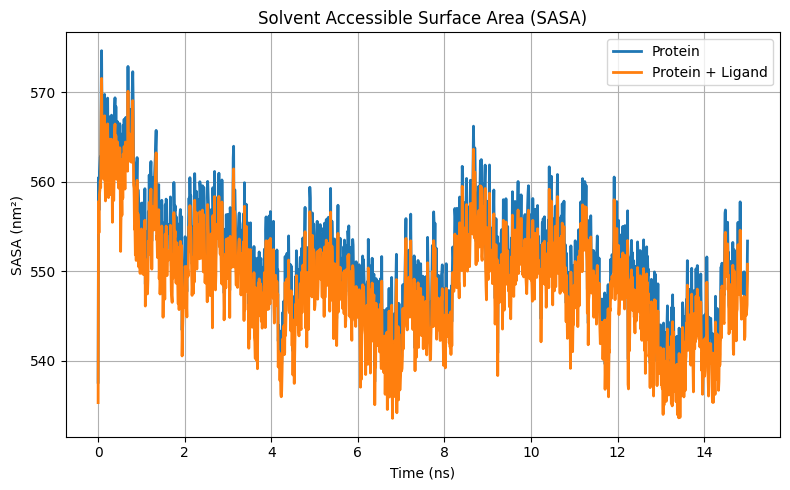

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Function to read .xvg file
def read_xvg(file):
    data = []
    with open(file, 'r') as f:
        for line in f:
            if line.startswith(('#', '@')):
                continue
            data.append([float(x) for x in line.split()])
    return np.array(data)

# Load files
sasa_protein = read_xvg('SASA.xvg')
sasa_complex = read_xvg('SASA-pro-lig.xvg')

# Extract time and SASA
time1 = sasa_protein[:, 0]
sasa1 = sasa_protein[:, 1]

time2 = sasa_complex[:, 0]
sasa2 = sasa_complex[:, 1]

# Convert ps → ns
time1 = time1 / 1000
time2 = time2 / 1000

# Plot
plt.figure(figsize=(8,5))

plt.plot(time1, sasa1, label='Protein', linewidth=2)
plt.plot(time2, sasa2, label='Protein + Ligand', linewidth=2)

# Labels
plt.xlabel('Time (ns)')
plt.ylabel('SASA (nm²)')
plt.title('Solvent Accessible Surface Area (SASA)')

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
!gmx hbond -s md_10_50.tpr -f md_fit_final.xtc -num hb.xvg -tu ns

                      :-) GROMACS - gmx hbond, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Load file
with open("hb.xvg") as f:
    lines = [line for line in f if not line.startswith(('@', '#'))]

# Parse data
cleaned = []
for line in lines:
    parts = re.split(r'\s+', line.strip())
    if len(parts) >= 3:
        cleaned.append(parts[:3])

# Create DataFrame
data = pd.DataFrame(cleaned, columns=["Time_ns", "HBonds", "Pairs"]).astype(float)

# Plot (NO conversion needed)
plt.figure(figsize=(10,5))
plt.plot(data["Time_ns"], data["HBonds"], label="Hydrogen Bonds", linewidth=1.5)
plt.plot(data["Time_ns"], data["Pairs"], linestyle="--", label="Pairs within 0.35 nm")

plt.xlabel("Time (ns)")
plt.ylabel("Number of H-Bonds")
plt.title("Hydrogen Bonds vs Time")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# RMSF
!gmx rmsf -s md_10_50.tpr -f md_fit_final.xtc -o rmsf-ca.xvg

                       :-) GROMACS - gmx rmsf, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

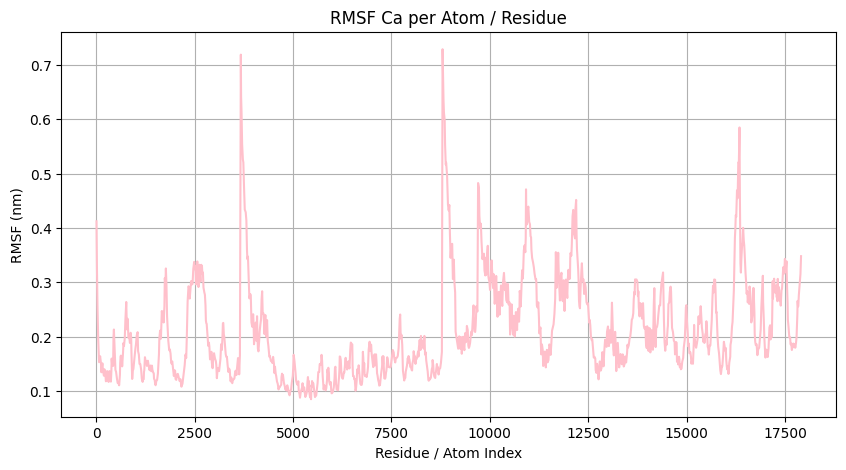

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Clean and load RMSF data ---
with open("rmsf-ca.xvg") as f:
    lines = [line for line in f if not line.startswith(('@', '#'))]

cleaned = []
for line in lines:
    parts = re.split(r'\s+', line.strip())
    if len(parts) >= 2:
        cleaned.append(parts[:2])

# --- Create DataFrame ---
data = pd.DataFrame(cleaned, columns=["Atom", "RMSF"]).astype(float)

# --- Plot RMSF ---
plt.figure(figsize=(10,5))
plt.plot(data["Atom"], data["RMSF"], color='pink')
plt.xlabel("Residue / Atom Index")
plt.ylabel("RMSF (nm)")
plt.title("RMSF Ca per Atom / Residue")
plt.grid(True)
plt.show()

In [5]:
# RMSF repeted
!gmx rmsf -s md_10_50.tpr -f md_fit_final.xtc -o rmsf-ca2.xvg -res

                       :-) GROMACS - gmx rmsf, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

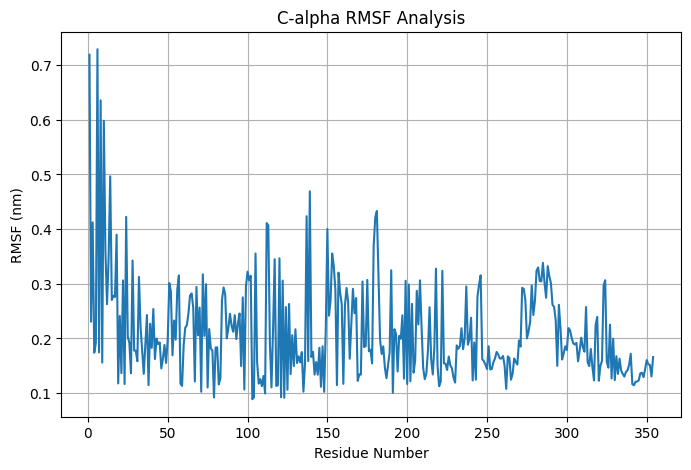

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Read RMSF file
data = []
with open("rmsf-ca2.xvg") as f:
    for line in f:
        if not line.startswith(('@', '#')):
            parts = line.split()
            data.append([float(parts[0]), float(parts[1])])

df = pd.DataFrame(data, columns=["Residue", "RMSF"])

# SORT by residue index (VERY IMPORTANT)
df = df.sort_values(by="Residue")

# Remove duplicates if any
df = df.drop_duplicates(subset="Residue")

# Plot
plt.figure(figsize=(8,5))
plt.plot(df["Residue"], df["RMSF"])
plt.xlabel("Residue Number")
plt.ylabel("RMSF (nm)")
plt.title("C-alpha RMSF Analysis")
plt.grid(True)
plt.show()

In [15]:
!gmx rmsf -s md_10_50.tpr -f md_fit_final.xtc -o rmsf-pro-lig.xvg -n index_n.ndx

                       :-) GROMACS - gmx rmsf, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

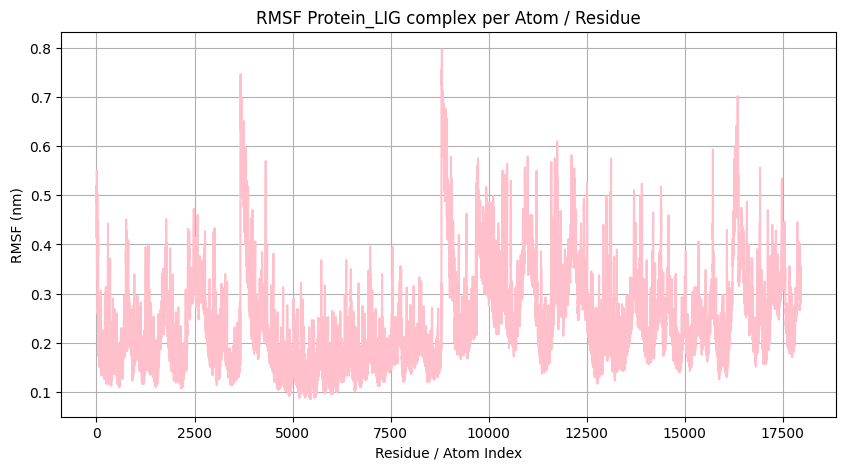

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Clean and load RMSF data ---
with open("rmsf-pro-lig.xvg") as f:
    lines = [line for line in f if not line.startswith(('@', '#'))]

cleaned = []
for line in lines:
    parts = re.split(r'\s+', line.strip())
    if len(parts) >= 2:
        cleaned.append(parts[:2])

# --- Create DataFrame ---
data = pd.DataFrame(cleaned, columns=["Atom", "RMSF"]).astype(float)

# --- Plot RMSF ---
plt.figure(figsize=(10,5))
plt.plot(data["Atom"], data["RMSF"], color='pink')
plt.xlabel("Residue / Atom Index")
plt.ylabel("RMSF (nm)")
plt.title("RMSF Protein_LIG complex per Atom / Residue")
plt.grid(True)
plt.show()

In [17]:
!gmx rmsf -s md_10_50.tpr -f md_fit_final.xtc -o rmsf-pro.xvg

                       :-) GROMACS - gmx rmsf, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios Karkoulis            Peter Kasson                Jiri Kraus        
      Carsten Kutzner              Per Larsson              Justin A. Lemkul     
       Viveca Lindahl            Magnus Lundborg             Erik Marklund       
        Pascal Merz             Pieter Meulenhoff            Teemu Mur

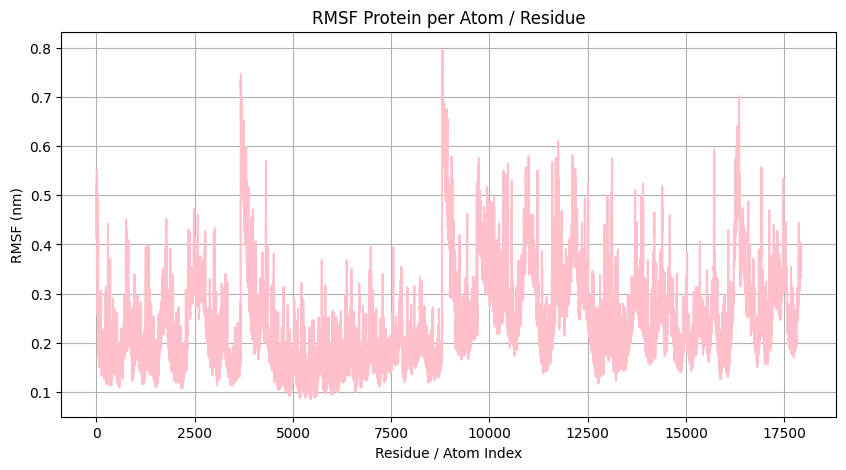

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Clean and load RMSF data ---
with open("rmsf-pro.xvg") as f:
    lines = [line for line in f if not line.startswith(('@', '#'))]

cleaned = []
for line in lines:
    parts = re.split(r'\s+', line.strip())
    if len(parts) >= 2:
        cleaned.append(parts[:2])

# --- Create DataFrame ---
data = pd.DataFrame(cleaned, columns=["Atom", "RMSF"]).astype(float)

# --- Plot RMSF ---
plt.figure(figsize=(10,5))
plt.plot(data["Atom"], data["RMSF"], color='pink')
plt.xlabel("Residue / Atom Index")
plt.ylabel("RMSF (nm)")
plt.title("RMSF Protein per Atom / Residue")
plt.grid(True)
plt.show()

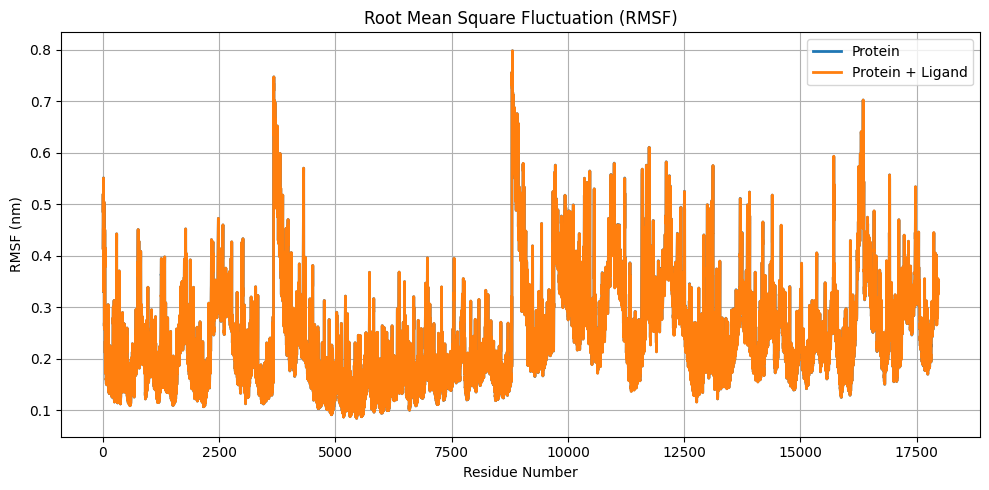

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Function to read .xvg file
def read_xvg(file):
    data = []
    with open(file, 'r') as f:
        for line in f:
            if line.startswith(('#', '@')):
                continue
            data.append([float(x) for x in line.split()])
    return np.array(data)

# Load files
rmsf_pro = read_xvg('rmsf-pro.xvg')
rmsf_complex = read_xvg('rmsf-pro-lig.xvg')

# Extract residue index and RMSF
res1 = rmsf_pro[:, 0]
rmsf1 = rmsf_pro[:, 1]

res2 = rmsf_complex[:, 0]
rmsf2 = rmsf_complex[:, 1]

# Plot
plt.figure(figsize=(10,5))

plt.plot(res1, rmsf1, label='Protein', linewidth=2)
plt.plot(res2, rmsf2, label='Protein + Ligand', linewidth=2)

# Labels
plt.xlabel('Residue Number')
plt.ylabel('RMSF (nm)')
plt.title('Root Mean Square Fluctuation (RMSF)')

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
# To make a trajectory movies open UCSF chimera and upload these files
# Download these 2 files:
# 	•	md_fit_final.xtc (THIS is final movie trajectory)
# 	•	md_10_50.tpr (structure/topology file)
